# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

In this project, the model is trained using the same training dataset created previously and evaluated on the unseen testing dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from pathlib import Path

# Project root directory
BASE_DIR = Path.cwd().parent

# Load the One-Hot Encoded dataset from Day 2
file_path = BASE_DIR / "Day 2" / "features_v1.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Target variable
y = df["Survived"]

# Feature matrix
X = df[
    [
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Sex_Male",
        "Embarked_Q",
        "Embarked_S"
    ]
]

print("Features and target created successfully!")

Features and target created successfully!


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test Split completed!")

Train-Test Split completed!


In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model initialized!")

Random Forest model initialized!


In [6]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


# Model Evaluation

The Random Forest model is evaluated using several classification metrics instead of relying only on accuracy.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

In [9]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

print("Evaluation libraries imported successfully!")

Evaluation libraries imported successfully!


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 83.80%


In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[93 12]
 [17 57]]


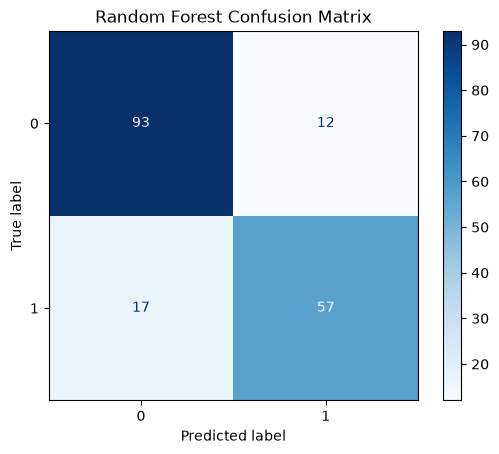

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.77      0.80        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [14]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print("Precision :", round(report["1"]["precision"], 3))
print("Recall    :", round(report["1"]["recall"], 3))
print("F1-Score  :", round(report["1"]["f1-score"], 3))

Precision : 0.826
Recall    : 0.77
F1-Score  : 0.797


# Model Comparison

The Random Forest Classifier was compared with the Logistic Regression baseline model created previously.

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees, making it capable of capturing more complex relationships in the data.

Unlike Logistic Regression, which assumes a linear relationship, Random Forest can model non-linear patterns and interactions between features.

The evaluation metrics such as Precision, Recall, and F1-Score provide a more complete understanding of model performance than accuracy alone.

In [15]:
joblib.dump(
    model,
    "random_forest_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Conclusion

In this project, a Random Forest Classifier was trained using the training dataset and evaluated using the testing dataset.

### Tasks Completed

- Loaded the cleaned dataset
- Created the training and testing datasets
- Trained a Random Forest Classifier
- Generated predictions
- Evaluated the model using:
  - Accuracy
  - Precision
  - Recall
  - F1-Score
  - Confusion Matrix
- Compared the Random Forest model with the Logistic Regression baseline
- Saved the trained model as a serialized .pkl file

The Random Forest model provides a strong baseline for classification and demonstrates the benefits of ensemble learning.